### PASO 2b: SEGMENTACIÓN CORRECTA — PERSPECTIVA WARPING

### ¿Por qué falla la segmentación actual? El notebook original 'Paso2' no se incluye porque, obviamente, falló.

Cuando haces `img[y1:y2, x1:x2]` con la bounding box de YOLO,
obtienes un recorte rectangular de la foto original.

El problema: **la foto casi nunca está tomada perfectamente de frente**.
Aunque sea un ángulo mínimo, las líneas de la cuadrícula no son
horizontales ni verticales, y al dividir el recorte entre 9:

```
Recorte actual (trapezoide):     Lo que queremos (cuadrado):
┌─────────────┐                  ┌───┬───┬───┐
│  ╱─────────╲│                  │   │   │   │
│ ╱  7  │    ╲│     →→→         ├───┼───┼───┤
│╱     ─┼─────│                  │ 7 │   │   │
│───────╱     │                  ├───┼───┼───┤
└─────────────┘                  └───┴───┴───┘
  Dígitos cortados/torcidos         Celdas perfectas
```

### Solución: perspective warp en 3 pasos

```
PASO 1: Encontrar los 4 contornos de la cuadrícula
        (usando el recorte de YOLO como punto de partida)
        ↓
PASO 2: Identificar las 4 esquinas (arriba-izq, arriba-der, abajo-der, abajo-izq)
        ↓  
PASO 3: cv2.getPerspectiveTransform() + cv2.warpPerspective()
        → transforma el trapezoide en un cuadrado perfecto de 450×450 px
        ↓
RESULTADO: 81 celdas de exactamente 50×50 px, limpias y alineadas
```

## CELDA 1 — Instalaciones e imports

In [21]:
# ============================================
# INSTALACIONES E IMPORTS
# ============================================

from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics tensorflow opencv-python-headless -q

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from ultralytics import YOLO

RUTA_SUDOKU = '/content/drive/MyDrive/sudoku/'
RUTA_YOLO   = RUTA_SUDOKU + 'modelo_yolo.pt'
RUTA_CNN    = RUTA_SUDOKU + 'modelo_digitos_v3.keras'
RUTA_TEST   = RUTA_SUDOKU + 'images/test/'

modelo_yolo = YOLO(RUTA_YOLO)
modelo_cnn  = keras.models.load_model(RUTA_CNN)

print("✅ Modelos cargados")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Modelos cargados


#### CELDA 2 — Diagnóstico

Esta celda no es imprescindible, es simplemente para entender por qúe con el recorte bounding box de YOLO las celdas quedan torcidas.

🖼️ Imagen: sudoku_3295_jpg.rf.FpFbVGMHTlUDCmSrYTCw.jpg

image 1/1 /content/drive/MyDrive/sudoku/images/test/sudoku_3295_jpg.rf.FpFbVGMHTlUDCmSrYTCw.jpg: 640x480 1 sudoku_grid, 156.7ms
Speed: 3.9ms preprocess, 156.7ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)

🔍 Recorte ACTUAL con la cuadrícula de segmentación:


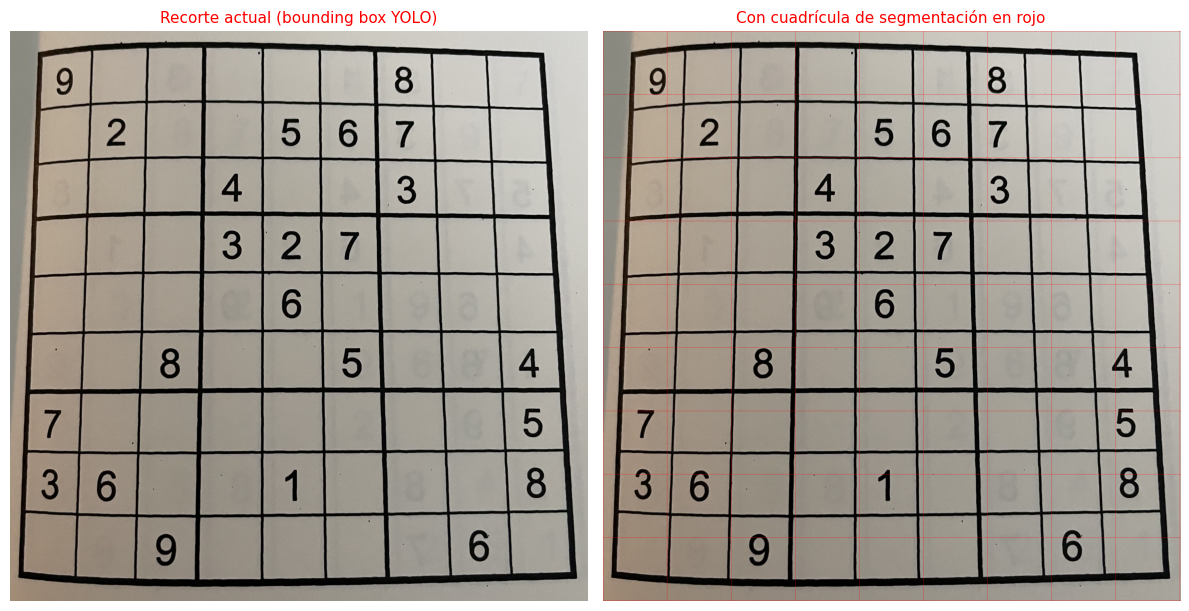


🔍 Primeras 9 celdas con el método ACTUAL:


/tmp/ipykernel_2592/2027445089.py:52: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


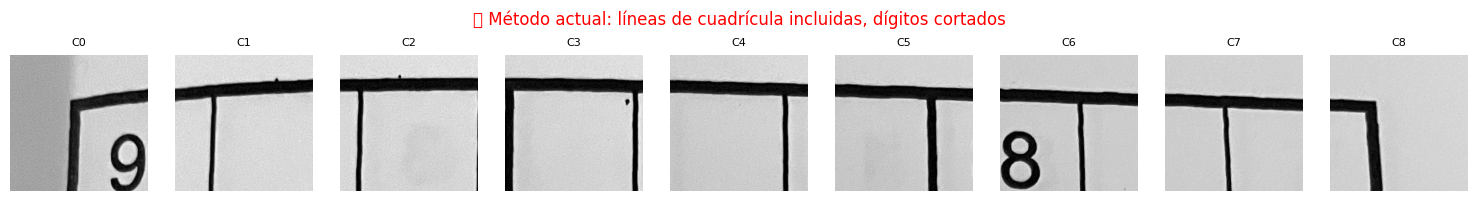


💡 Fíjate en:
   - Las líneas negras de la cuadrícula que entran en las celdas
   - Los dígitos que no están centrados o aparecen cortados
   - El ángulo leve de toda la imagen


In [22]:
# ============================================
# DIAGNÓSTICO: EL PROBLEMA ACTUAL
# ============================================

# Cargar imagen de test
imagen_test   = [f for f in os.listdir(RUTA_TEST) if f.endswith(('.jpg','.png'))][0]
ruta_completa = RUTA_TEST + imagen_test
print(f"🖼️ Imagen: {imagen_test}")

img     = cv2.imread(ruta_completa)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Detectar con YOLO
results = modelo_yolo(ruta_completa)
box     = results[0].boxes[0]
x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

# Recorte actual (método viejo)
grid_viejo = img_rgb[y1:y2, x1:x2]
h, w       = grid_viejo.shape[:2]
cell_h, cell_w = h // 9, w // 9

# Mostrar el recorte actual con la cuadrícula dibujada
print("\n🔍 Recorte ACTUAL con la cuadrícula de segmentación:")
grid_con_lineas = grid_viejo.copy()
for i in range(10):
    y = i * cell_h
    x = i * cell_w
    cv2.line(grid_con_lineas, (0, y), (w, y), (255, 0, 0), 1)   # líneas horizontales en rojo
    cv2.line(grid_con_lineas, (x, 0), (x, h), (255, 0, 0), 1)   # líneas verticales en rojo

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(grid_viejo)
axes[0].set_title('Recorte actual (bounding box YOLO)', color='red', fontsize=11)
axes[0].axis('off')
axes[1].imshow(grid_con_lineas)
axes[1].set_title('Con cuadrícula de segmentación en rojo', color='red', fontsize=11)
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Mostrar las primeras 9 celdas extraídas con el método actual
print("\n🔍 Primeras 9 celdas con el método ACTUAL:")
gray_viejo = cv2.cvtColor(grid_viejo, cv2.COLOR_RGB2GRAY)
fig, axes  = plt.subplots(1, 9, figsize=(15, 2))
for j in range(9):
    celda = gray_viejo[0:cell_h, j*cell_w:(j+1)*cell_w]
    axes[j].imshow(celda, cmap='gray')
    axes[j].set_title(f'C{j}', fontsize=8)
    axes[j].axis('off')
plt.suptitle('❌ Método actual: líneas de cuadrícula incluidas, dígitos cortados', color='red')
plt.tight_layout()
plt.show()

print("\n💡 Fíjate en:")
print("   - Las líneas negras de la cuadrícula que entran en las celdas")
print("   - Los dígitos que no están centrados o aparecen cortados")
print("   - El ángulo leve de toda la imagen")

#### CELDA 3 — La solución: encontrar las 4 esquinas reales

En lugar de usar la bounding box rectangular de YOLO, OPenCV busca el contorno real de la cuadrícula y extrae sus 4 esquinas exactas.

🔍 Buscando las 4 esquinas de la cuadrícula...
   Contorno más grande: 5871670 px²  (84% del recorte)
   Puntos del contorno aproximado: 4

✅ Esquinas encontradas:
   Punto 0: (364, 934)
   Punto 1: (278, 3314)
   Punto 2: (2803, 3317)
   Punto 3: (2654, 934)


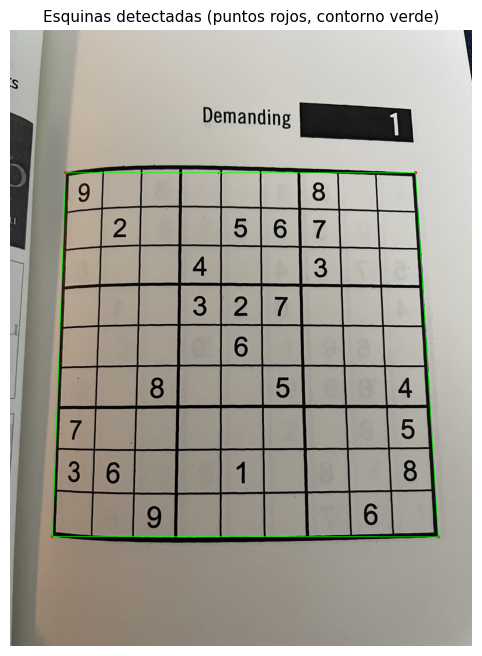

In [23]:
# ============================================
# FUNCIÓN 1: ENCONTRAR LAS 4 ESQUINAS
# ============================================

def encontrar_esquinas(img_rgb, box_yolo):
    """
    Encuentra las 4 esquinas reales de la cuadrícula del sudoku.

    Estrategia:
    1. Recortamos la zona donde YOLO detectó la cuadrícula (con margen)
    2. Binarizamos y buscamos el contorno más grande
    3. Lo aproximamos a un cuadrilátero de 4 puntos
    4. Devolvemos esos 4 puntos en coordenadas de la imagen original

    Entrada: imagen RGB completa, bounding box de YOLO
    Salida:  array de 4 puntos [[x,y], ...] o None si falla
    """
    x1, y1, x2, y2 = box_yolo

    # ── PASO 1: Recortar zona con un margen extra ────────────────────────
    # Añadimos margen para no cortar las esquinas de la cuadrícula
    margen = 20
    H, W   = img_rgb.shape[:2]
    rx1 = max(0, x1 - margen)
    ry1 = max(0, y1 - margen)
    rx2 = min(W, x2 + margen)
    ry2 = min(H, y2 + margen)

    recorte = img_rgb[ry1:ry2, rx1:rx2]

    # ── PASO 2: Preprocesar para encontrar contornos ─────────────────────
    gray = cv2.cvtColor(recorte, cv2.COLOR_RGB2GRAY)

    # Desenfoque gaussiano para eliminar ruido
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Binarización adaptativa: funciona mejor que Otsu para imágenes
    # con iluminación no uniforme (sombras en las esquinas)
    binaria = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # umbral adaptativo por zona
        cv2.THRESH_BINARY_INV,           # invertir: cuadrícula = blanco
        11, 4                            # tamaño de vecindad, constante C
    )

    # ── PASO 3: Encontrar contornos ──────────────────────────────────────
    contornos, _ = cv2.findContours(
        binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if not contornos:
        print("   ⚠️ No se encontraron contornos")
        return None

    # El contorno más grande debería ser la cuadrícula del sudoku
    contorno_mayor = max(contornos, key=cv2.contourArea)
    area_contorno  = cv2.contourArea(contorno_mayor)
    area_recorte   = (rx2 - rx1) * (ry2 - ry1)

    print(f"   Contorno más grande: {area_contorno:.0f} px²  "
          f"({area_contorno/area_recorte:.0%} del recorte)")

    # Si el contorno es muy pequeño, algo salió mal
    if area_contorno < 0.3 * area_recorte:
        print("   ⚠️ Contorno demasiado pequeño, usando bounding box directamente")
        return None

    # ── PASO 4: Aproximar a 4 puntos ────────────────────────────────────
    # epsilon controla cuánto simplificamos el contorno
    # Con 0.02 del perímetro obtenemos los 4 vértices principales
    epsilon    = 0.02 * cv2.arcLength(contorno_mayor, True)
    approx     = cv2.approxPolyDP(contorno_mayor, epsilon, True)

    print(f"   Puntos del contorno aproximado: {len(approx)}")

    # Si no tenemos exactamente 4 puntos, probamos con epsilon más grande
    intentos = 0
    while len(approx) != 4 and intentos < 10:
        epsilon  = epsilon * 1.2
        approx   = cv2.approxPolyDP(contorno_mayor, epsilon, True)
        intentos += 1

    if len(approx) != 4:
        print(f"   ⚠️ No se pudo reducir a 4 puntos ({len(approx)} encontrados)")
        print(f"   → Usando bounding rect como fallback")
        # Fallback: usar el bounding rect del contorno
        rect   = cv2.minAreaRect(contorno_mayor)
        approx = cv2.boxPoints(rect).reshape(-1, 1, 2).astype(int)

    # ── PASO 5: Convertir a coordenadas de la imagen original ────────────
    # Los puntos están en coordenadas del recorte, los pasamos a la imagen completa
    puntos = approx.reshape(-1, 2).astype(np.float32)
    puntos[:, 0] += rx1   # desplazar en X
    puntos[:, 1] += ry1   # desplazar en Y

    return puntos


# ── Probar ───────────────────────────────────────────────────────────────
print("🔍 Buscando las 4 esquinas de la cuadrícula...")
esquinas = encontrar_esquinas(img_rgb, (x1, y1, x2, y2))

if esquinas is not None:
    print(f"\n✅ Esquinas encontradas:")
    for i, (px, py) in enumerate(esquinas):
        print(f"   Punto {i}: ({px:.0f}, {py:.0f})")

    # Mostrar las esquinas sobre la imagen
    img_debug = img_rgb.copy()
    for px, py in esquinas:
        cv2.circle(img_debug, (int(px), int(py)), 10, (255, 0, 0), -1)
    cv2.polylines(img_debug, [esquinas.astype(int)], True, (0, 255, 0), 3)

    plt.figure(figsize=(8, 8))
    plt.imshow(img_debug)
    plt.title('Esquinas detectadas (puntos rojos, contorno verde)', fontsize=11)
    plt.axis('off')
    plt.show()
else:
    print("\n⚠️ Usando bounding box de YOLO como fallback")

#### CELDA 4 — Ordenar las esquinas y aplicar el warp

Las 4 esquinas pueden venir en cualquier orden. Necesitamos ordenarlas
siempre igual: arriba-izquierda, arriba-derecha, abajo-derecha, abajo-izquierda.
Después aplicamos la transformación de perspectiva.

🔄 Aplicando transformación de perspectiva...


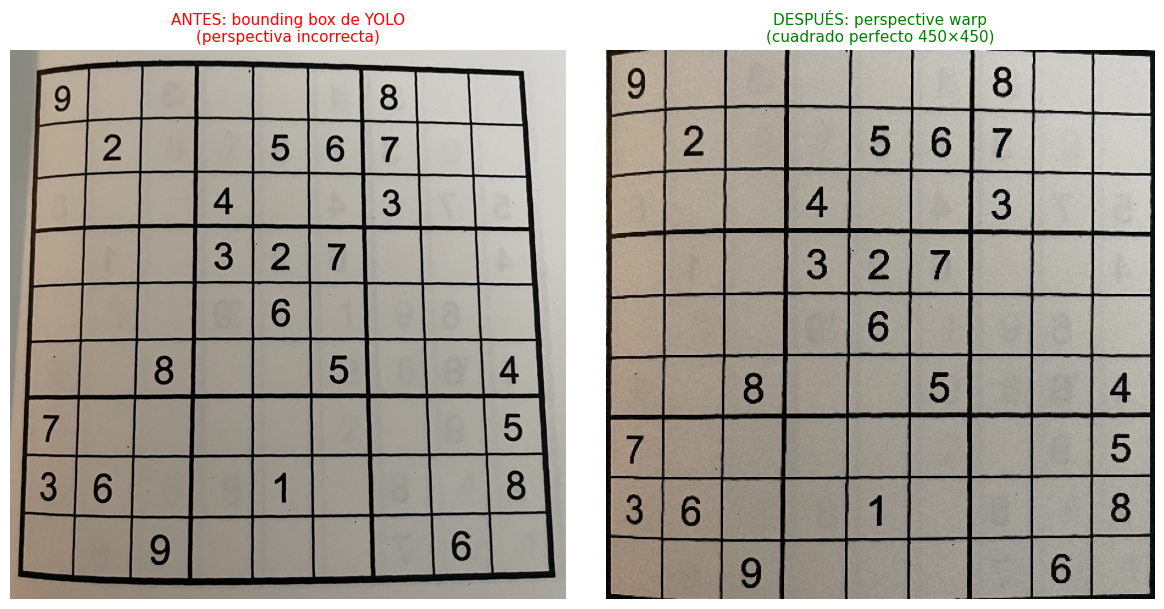


✅ Grid warped: (450, 450, 3)

💡 El grid warped debe verse perfectamente recto y cuadrado.
   Si se ve distorsionado, el problema está en las esquinas detectadas.


In [24]:
# ============================================
# FUNCIÓN 2: ORDENAR ESQUINAS Y APLICAR WARP
# ============================================

def ordenar_esquinas(puntos):
    """
    Ordena 4 puntos en este orden: [arriba-izq, arriba-der, abajo-der, abajo-izq]

    Truco:
    - Arriba-izq  → menor suma (x+y)
    - Abajo-der   → mayor suma (x+y)
    - Arriba-der  → menor diferencia (x-y)
    - Abajo-izq   → mayor diferencia (x-y)
    """
    puntos  = puntos.reshape(4, 2)
    ordered = np.zeros((4, 2), dtype=np.float32)

    sumas        = puntos.sum(axis=1)     # x + y para cada punto
    diferencias  = np.diff(puntos, axis=1).flatten()  # x - y para cada punto

    ordered[0] = puntos[np.argmin(sumas)]         # arriba-izquierda
    ordered[2] = puntos[np.argmax(sumas)]         # abajo-derecha
    ordered[1] = puntos[np.argmin(diferencias)]   # arriba-derecha
    ordered[3] = puntos[np.argmax(diferencias)]   # abajo-izquierda

    return ordered


def warp_perspectiva(img_rgb, esquinas, tamaño=450):
    """
    Transforma la cuadrícula torcida en un cuadrado perfecto.

    Entrada: imagen completa, 4 esquinas ordenadas, tamaño del cuadrado destino
    Salida:  imagen cuadrada de tamaño×tamaño píxeles

    cv2.getPerspectiveTransform: calcula la matriz de transformación
    que mapea los 4 puntos de origen a los 4 puntos de destino.

    cv2.warpPerspective: aplica esa transformación a la imagen completa.
    """
    # Puntos de origen: las 4 esquinas reales de la cuadrícula
    origen = ordenar_esquinas(esquinas)

    # Puntos de destino: un cuadrado perfecto de tamaño×tamaño
    destino = np.float32([
        [0,      0],        # arriba-izquierda
        [tamaño, 0],        # arriba-derecha
        [tamaño, tamaño],   # abajo-derecha
        [0,      tamaño]    # abajo-izquierda
    ])

    # Calcular la matriz de transformación de perspectiva
    M = cv2.getPerspectiveTransform(origen, destino)

    # Aplicar la transformación
    grid_warped = cv2.warpPerspective(img_rgb, M, (tamaño, tamaño))

    return grid_warped


# ── Probar el warp ───────────────────────────────────────────────────────
print("🔄 Aplicando transformación de perspectiva...")

if esquinas is not None:
    grid_warped = warp_perspectiva(img_rgb, esquinas, tamaño=450)
else:
    # Fallback: usar las 4 esquinas de la bounding box de YOLO
    print("   Usando bounding box de YOLO como fallback")
    esquinas_fallback = np.float32([[x1, y1], [x2, y1], [x2, y2], [x1, y2]])
    grid_warped = warp_perspectiva(img_rgb, esquinas_fallback, tamaño=450)

# Comparar antes y después
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(grid_viejo)
axes[0].set_title('ANTES: bounding box de YOLO\n(perspectiva incorrecta)', color='red', fontsize=11)
axes[0].axis('off')
axes[1].imshow(grid_warped)
axes[1].set_title('DESPUÉS: perspective warp\n(cuadrado perfecto 450×450)', color='green', fontsize=11)
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"\n✅ Grid warped: {grid_warped.shape}")
print("\n💡 El grid warped debe verse perfectamente recto y cuadrado.")
print("   Si se ve distorsionado, el problema está en las esquinas detectadas.")

#### CELDA 5 — Segmentar las 81 celdas del grid warped

Ahora que el grid es un cuadrado perfecto de 450×450 px,
cada celda ocupa exactamente 50×50 px. Además aplicamos
un recorte de margen dentro de cada celda para eliminar las líneas.

✂️  Segmentando en 81 celdas...
✅ 81 celdas extraídas


/tmp/ipykernel_2592/933268370.py:79: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


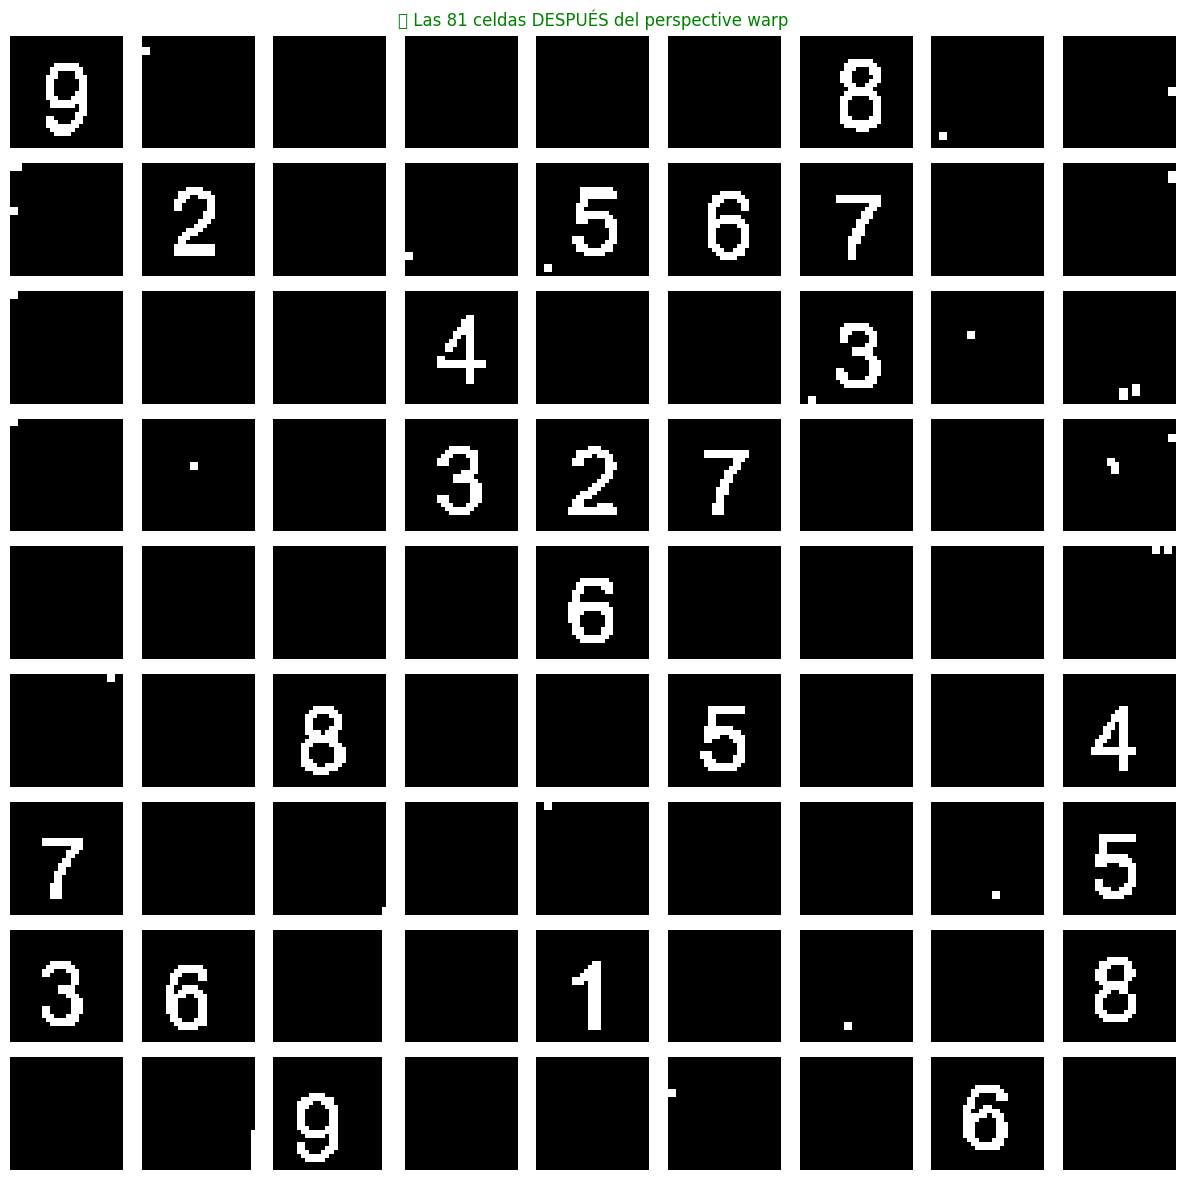


💡 Ahora las celdas deben verse:
   - Sin líneas de cuadrícula en los bordes
   - Dígitos centrados y completos
   - Fondo negro, dígito blanco (como MNIST)


In [37]:
# ============================================
# FUNCIÓN 3: SEGMENTAR EN 81 CELDAS LIMPIAS
# ============================================

def segmentar_celdas(grid_warped, tamaño_celda=50, margen=4):
    """
    Divide el grid warped en 81 celdas limpias.

    Entrada: grid warped (450×450 RGB)
    Salida:  lista de 81 celdas en escala de grises, preprocesadas (28×28, float32)

    El margen recorta las líneas de la cuadrícula de los bordes de cada celda.
    Con tamaño_celda=50 y margen=4, cada celda útil es de 42×42 px.
    """
    gray    = cv2.cvtColor(grid_warped, cv2.COLOR_RGB2GRAY)
    celdas  = []

    for i in range(9):       # filas
        for j in range(9):   # columnas
            # Coordenadas de la celda
            y1c = i * tamaño_celda
            y2c = (i + 1) * tamaño_celda
            x1c = j * tamaño_celda
            x2c = (j + 1) * tamaño_celda

            # Extraer celda completa
            celda = gray[y1c:y2c, x1c:x2c]

            # ── Recortar margen (eliminar líneas de cuadrícula) ──────────
            # Quitamos 'margen' píxeles por cada lado
            margen_izq = margen + 3 if j == 0 else margen
            margen_arr = margen + 3 if i == 0 else margen
            celda_sin_bordes = celda[margen_arr:tamaño_celda-margen,
                         margen_izq:tamaño_celda-margen]

            # ── Redimensionar a 28×28 (tamaño MNIST) ────────────────────
            celda_28 = cv2.resize(celda_sin_bordes, (28, 28))

            # ── Binarizar con umbral adaptativo ─────────────────────────
            # adaptativeThreshold funciona mejor que Otsu para celdas vacías
            # porque usa el contexto local en lugar de un umbral global
            celda_bin = cv2.adaptiveThreshold(
            celda_28, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,  # INV = fondo negro, dígito blanco (como MNIST)
            11, 4                   # vecindad 11px, constante C=4
            )

            # ── Eliminar ruido pequeño ───────────────────────────────────
            kernel    = np.ones((2, 2), np.uint8)
            celda_bin = cv2.morphologyEx(celda_bin, cv2.MORPH_OPEN, kernel)

            # ── Normalizar a [0, 1] ──────────────────────────────────────
            celda_norm = celda_bin.astype('float32') / 255.0
            celdas.append(celda_norm)

    return celdas   # lista de 81 arrays (28, 28)


# ── Extraer y mostrar las 81 celdas ─────────────────────────────────────
print("✂️  Segmentando en 81 celdas...")
celdas = segmentar_celdas(grid_warped)
print(f"✅ {len(celdas)} celdas extraídas")

# Mostrar las 81 celdas
fig, axes = plt.subplots(9, 9, figsize=(12, 12))
for idx, celda in enumerate(celdas):
    i, j = idx // 9, idx % 9
    axes[i][j].imshow(celda, cmap='gray', vmin=0, vmax=1)
    axes[i][j].axis('off')

    # Borde más grueso en bloques 3×3
    for spine in axes[i][j].spines.values():
        spine.set_linewidth(0.3)
    if i % 3 == 0: axes[i][j].spines['top'].set_linewidth(2)
    if j % 3 == 0: axes[i][j].spines['left'].set_linewidth(2)

plt.suptitle('✅ Las 81 celdas DESPUÉS del perspective warp', fontsize=12, color='green')
plt.tight_layout()
plt.show()

print("\n💡 Ahora las celdas deben verse:")
print("   - Sin líneas de cuadrícula en los bordes")
print("   - Dígitos centrados y completos")
print("   - Fondo negro, dígito blanco (como MNIST)")

#### CELDA 6 — Comparar: celdas antes y después del warp

Esta celda tampoco es imprescindible, muestra la misma fila del sudoku con sendos métodos.

🔬 Comparando la primera fila: método ANTERIOR vs NUEVO:


/tmp/ipykernel_2592/3311875795.py:38: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2592/3311875795.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


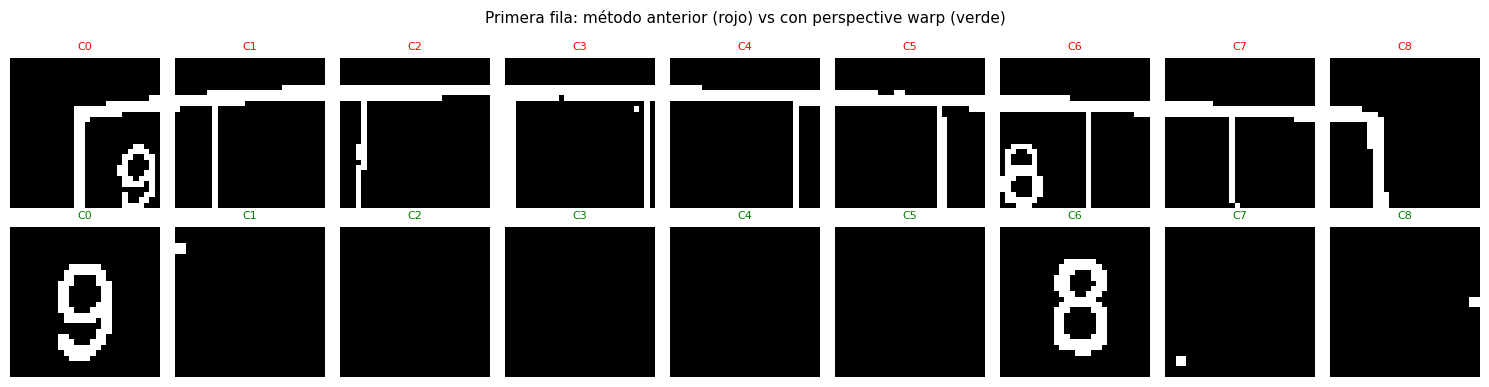

In [38]:
# ============================================
# COMPARACIÓN: ANTES vs DESPUÉS del warp
# ============================================

print("🔬 Comparando la primera fila: método ANTERIOR vs NUEVO:")

gray_viejo = cv2.cvtColor(grid_viejo, cv2.COLOR_RGB2GRAY)
cell_h_viejo = gray_viejo.shape[0] // 9
cell_w_viejo = gray_viejo.shape[1] // 9

fig, axes = plt.subplots(2, 9, figsize=(15, 4))

for j in range(9):
    # ── Método ANTERIOR ──────────────────────────────────────────────────
    celda_vieja_raw = gray_viejo[0:cell_h_viejo, j*cell_w_viejo:(j+1)*cell_w_viejo]
    celda_vieja     = cv2.resize(celda_vieja_raw, (28, 28))
    _, celda_vieja_bin = cv2.threshold(celda_vieja, 0, 255,
                                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(celda_vieja_bin) > 127:
        celda_vieja_bin = cv2.bitwise_not(celda_vieja_bin)

    # ── Método NUEVO (warp) ───────────────────────────────────────────────
    celda_nueva = celdas[j]   # primera fila = índices 0-8

    axes[0][j].imshow(celda_vieja_bin, cmap='gray')
    axes[0][j].set_title(f'C{j}', fontsize=8, color='red')
    axes[0][j].axis('off')

    axes[1][j].imshow(celda_nueva, cmap='gray')
    axes[1][j].set_title(f'C{j}', fontsize=8, color='green')
    axes[1][j].axis('off')

axes[0][0].set_ylabel('❌ Anterior', fontsize=9, color='red', rotation=0, labelpad=45)
axes[1][0].set_ylabel('✅ Con warp', fontsize=9, color='green', rotation=0, labelpad=45)

plt.suptitle('Primera fila: método anterior (rojo) vs con perspective warp (verde)',
             fontsize=11)
plt.tight_layout()
plt.show()

#### CELDA 7 — Función de detección y reconocimiento

Con las celdas ya limpias, la función de detección y reconocimiento
puede trabajar con umbrales mucho más ajustados.

In [39]:
# ============================================
# FUNCIONES DE DETECCIÓN Y RECONOCIMIENTO
# ============================================

def hay_digito(celda_norm, umbral_area=0.06):
    """
    Versión simplificada: mide directamente el área de píxeles blancos.
    Con el warp las celdas ya están limpias, no necesitamos filtro de forma.
    """
    area_bruta = float(np.sum(celda_norm > 0.5) / (28 * 28))
    return area_bruta > umbral_area, area_bruta


def reconocer_digito(celda_norm, modelo_cnn, umbral_confianza=0.70):
    """Pasa la celda por la CNN y devuelve el dígito y su confianza."""
    entrada = celda_norm.reshape(1, 28, 28, 1)
    pred    = modelo_cnn.predict(entrada, verbose=0)[0]
    pred[0] = 0.0                  # en sudoku no existe el dígito 0
    pred    = pred / pred.sum()
    digito  = int(np.argmax(pred))
    conf    = float(pred[digito])
    if conf < umbral_confianza:
        return 0, conf
    return digito, conf


def procesar_celda(celda_norm, modelo_cnn):
    """Pipeline completo para una celda: ¿hay dígito? → ¿cuál es?"""
    tiene, proporcion = hay_digito(celda_norm)
    if not tiene:
        return 0, 1.0, 'Vacío'
    digito, conf = reconocer_digito(celda_norm, modelo_cnn)
    if digito == 0:
        return 0, conf, 'Dudoso'
    return digito, conf, 'CNN'


print("✅ Funciones definidas")

✅ Funciones definidas


#### CELDA 8 — Pipeline completo: imagen → matriz 9×9

In [40]:
# ============================================
# PIPELINE COMPLETO MEJORADO
# ============================================

def imagen_a_matriz_v2(imagen_path, modelo_yolo, modelo_cnn):
    """
    Pipeline completo con perspective warp.
    Reemplaza al imagen_a_matriz() del Paso 3b.
    """
    print("="*60)
    print("🚀 PIPELINE v2: con perspective warp")
    print("="*60)

    img     = cv2.imread(imagen_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ── FASE 1: YOLO ─────────────────────────────────────────────────────
    print("\n📌 Fase 1: YOLO...")
    results = modelo_yolo(imagen_path)
    if len(results[0].boxes) == 0:
        return None, None, "❌ YOLO no detectó la cuadrícula"

    box  = results[0].boxes[0]
    conf = float(box.conf[0])
    print(f"   ✅ Confianza YOLO: {conf:.0%}")
    if conf < 0.5:
        return None, None, "❌ Confianza YOLO demasiado baja"

    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

    # ── FASE 2: Perspective warp ─────────────────────────────────────────
    print("\n📌 Fase 2: Perspective warp...")
    esquinas = encontrar_esquinas(img_rgb, (x1, y1, x2, y2))

    if esquinas is not None:
        grid_warped = warp_perspectiva(img_rgb, esquinas, tamaño=450)
        print("   ✅ Warp aplicado con esquinas reales")
    else:
        # Fallback: usar bounding box de YOLO directamente
        esquinas_fb = np.float32([[x1,y1],[x2,y1],[x2,y2],[x1,y2]])
        grid_warped = warp_perspectiva(img_rgb, esquinas_fb, tamaño=450)
        print("   ⚠️ Warp con bounding box (fallback)")

    # ── FASE 3: Segmentar en 81 celdas ───────────────────────────────────
    print("\n📌 Fase 3: Segmentando 81 celdas...")
    celdas = segmentar_celdas(grid_warped)
    print(f"   ✅ {len(celdas)} celdas extraídas")

    # ── FASE 4: Reconocer dígitos ─────────────────────────────────────────
    print("\n📌 Fase 4: Reconociendo dígitos...")
    matriz = np.zeros((9, 9), dtype=int)
    confs  = np.zeros((9, 9))
    n_dig  = 0
    n_dud  = 0

    for idx, celda in enumerate(celdas):
        i, j = idx // 9, idx % 9
        digito, conf_c, estado = procesar_celda(celda, modelo_cnn)
        matriz[i][j] = digito
        confs[i][j]  = conf_c
        if estado == 'CNN':    n_dig += 1
        elif estado == 'Dudoso': n_dud += 1

    print(f"   ✅ Dígitos detectados: {n_dig}")
    if n_dud: print(f"   ⚠️ Dudosos: {n_dud}")

    resumen = f"✅ {n_dig} dígitos"
    if n_dud: resumen += f" | ⚠️ {n_dud} dudosos"
    return matriz, grid_warped, resumen


# ── Ejecutar ─────────────────────────────────────────────────────────────
matriz, grid_warped_result, resumen = imagen_a_matriz_v2(
    ruta_completa, modelo_yolo, modelo_cnn
)

if matriz is not None:
    print(f"\n📊 {resumen}")
    print("\n📊 MATRIZ DETECTADA:")
    print("   ┌─────────┬─────────┬─────────┐")
    for i, fila in enumerate(matriz):
        if i > 0 and i % 3 == 0:
            print("   ├─────────┼─────────┼─────────┤")
        s = ""
        for j, n in enumerate(fila):
            if j % 3 == 0: s += "│ "
            s += (str(int(n)) if n else ".") + " "
        print(f"   {s}│")
    print("   └─────────┴─────────┴─────────┘")

🚀 PIPELINE v2: con perspective warp

📌 Fase 1: YOLO...

image 1/1 /content/drive/MyDrive/sudoku/images/test/sudoku_3295_jpg.rf.FpFbVGMHTlUDCmSrYTCw.jpg: 640x480 1 sudoku_grid, 156.9ms
Speed: 4.3ms preprocess, 156.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)
   ✅ Confianza YOLO: 99%

📌 Fase 2: Perspective warp...
   Contorno más grande: 5871670 px²  (84% del recorte)
   Puntos del contorno aproximado: 4
   ✅ Warp aplicado con esquinas reales

📌 Fase 3: Segmentando 81 celdas...
   ✅ 81 celdas extraídas

📌 Fase 4: Reconociendo dígitos...
   ✅ Dígitos detectados: 23

📊 ✅ 23 dígitos

📊 MATRIZ DETECTADA:
   ┌─────────┬─────────┬─────────┐
   │ 9 . . │ . . . │ 8 . . │
   │ . 2 . │ . 5 6 │ 7 . . │
   │ . . . │ 4 . . │ 3 . . │
   ├─────────┼─────────┼─────────┤
   │ . . . │ 3 2 7 │ . . . │
   │ . . . │ . 6 . │ . . . │
   │ . . 8 │ . . 5 │ . . 4 │
   ├─────────┼─────────┼─────────┤
   │ 7 . . │ . . . │ . . 5 │
   │ 3 6 . │ . 1 . │ . . 8 │
   │ . . 9 │ . . . │ . 6 . │
   └

#### CELDA 9 — Resolver con backtracking y mostrar resultado

In [41]:
# ============================================
# RESOLVER Y MOSTRAR RESULTADO
# ============================================

def es_valido(tablero, fila, col, num):
    if num in tablero[fila]: return False
    if num in [tablero[i][col] for i in range(9)]: return False
    fi = (fila // 3) * 3
    ci = (col  // 3) * 3
    for i in range(fi, fi+3):
        for j in range(ci, ci+3):
            if tablero[i][j] == num: return False
    return True

def resolver_sudoku(tablero):
    for i in range(9):
        for j in range(9):
            if tablero[i][j] == 0:
                for num in range(1, 10):
                    if es_valido(tablero, i, j, num):
                        tablero[i][j] = num
                        if resolver_sudoku(tablero): return True
                        tablero[i][j] = 0
                return False
    return True


if matriz is not None:
    n_pistas = int(np.sum(matriz > 0))

    if n_pistas < 17:
        print(f"❌ Solo {n_pistas} pistas. Mínimo 17 para resolver.")
    else:
        sudoku = matriz.copy()
        if resolver_sudoku(sudoku):
            print("✅ ¡SUDOKU RESUELTO!")
            print("   ┌─────────┬─────────┬─────────┐")
            for i, fila in enumerate(sudoku):
                if i > 0 and i % 3 == 0:
                    print("   ├─────────┼─────────┼─────────┤")
                s = ""
                for j, n in enumerate(fila):
                    if j % 3 == 0: s += "│ "
                    # Mostrar en verde los números que pusimos nosotros
                    s += str(int(n)) + " "
                print(f"   {s}│")
            print("   └─────────┴─────────┴─────────┘")
        else:
            print("❌ No tiene solución.")
            print("\n💡 Comprueba cuántos dígitos se detectaron correctamente.")
            print("   Si son muy pocos o hay errores, el problema sigue siendo la CNN.")
            print("   Siguiente paso: etiquetar celdas manualmente para reentrenar.")

✅ ¡SUDOKU RESUELTO!
   ┌─────────┬─────────┬─────────┐
   │ 9 4 1 │ 2 7 3 │ 8 5 6 │
   │ 8 2 3 │ 9 5 6 │ 7 4 1 │
   │ 5 7 6 │ 4 8 1 │ 3 9 2 │
   ├─────────┼─────────┼─────────┤
   │ 1 5 4 │ 3 2 7 │ 6 8 9 │
   │ 2 9 7 │ 8 6 4 │ 5 1 3 │
   │ 6 3 8 │ 1 9 5 │ 2 7 4 │
   ├─────────┼─────────┼─────────┤
   │ 7 1 2 │ 6 4 8 │ 9 3 5 │
   │ 3 6 5 │ 7 1 9 │ 4 2 8 │
   │ 4 8 9 │ 5 3 2 │ 1 6 7 │
   └─────────┴─────────┴─────────┘


#### CELDA 10 — Diagnóstico de dónde está el error en caso de fallo

Esta celda tampoco es imprescindible, se añadió durante el proceso para averiguar si el warp funcionó pero la CNN todavía fallaba, y determinar exactamente en qué celdas se equivoca. 
Esta celda resultó muy útil para decidir que era preciso etiquetar datos manualmente (Paso4).

🔍 Mostrando las celdas donde se detectó un dígito:
   (Comprueba visualmente si la predicción es correcta)


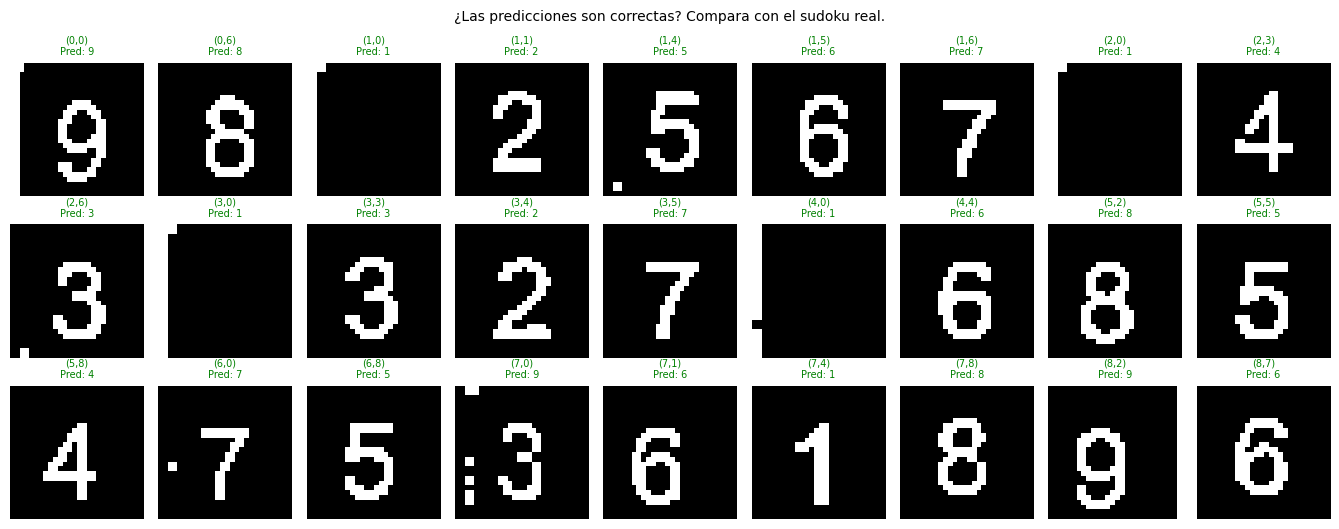


💡 Si las celdas se ven bien (sin líneas, dígito centrado)
   pero la predicción es incorrecta → problema en la CNN.
   Solución: etiquetar ~200 celdas manualmente para reentrenar.

   Si las celdas todavía se ven mal → ajusta el margen
   en segmentar_celdas() (prueba margen=6 o margen=8).


In [36]:
# ============================================
# DIAGNÓSTICO FINAL: ¿DÓNDE SIGUE FALLANDO?
# ============================================

if matriz is not None and grid_warped_result is not None:
    print("🔍 Mostrando las celdas donde se detectó un dígito:")
    print("   (Comprueba visualmente si la predicción es correcta)")

    celdas_nuevas = segmentar_celdas(grid_warped_result)

    posiciones = [(i, j) for i in range(9) for j in range(9)
                  if matriz[i][j] > 0]

    if not posiciones:
        print("\n❌ No se detectó ningún dígito.")
        print("   El problema puede ser:")
        print("   1. El warp no quedó bien (mira la celda 4)")
        print("   2. El umbral de área es demasiado alto (bájalo a 0.05 en hay_digito())")
        print("   3. La CNN sigue sin reconocer la tipografía impresa")
    else:
        # Mostrar todas las celdas con dígito
        n_mostrar = len(posiciones)
        cols      = min(9, n_mostrar)
        filas_plot = (n_mostrar + cols - 1) // cols

        fig, axes = plt.subplots(filas_plot, cols,
                                  figsize=(cols * 1.5, filas_plot * 1.8))
        if filas_plot == 1: axes = [axes]
        if cols == 1: axes = [[ax] for ax in axes]

        for idx, (i, j) in enumerate(posiciones):
            fila_plot = idx // cols
            col_plot  = idx % cols
            celda     = celdas_nuevas[i * 9 + j]
            pred      = matriz[i][j]

            axes[fila_plot][col_plot].imshow(celda, cmap='gray')
            axes[fila_plot][col_plot].set_title(
                f'({i},{j})\nPred: {pred}', fontsize=7, color='green'
            )
            axes[fila_plot][col_plot].axis('off')

        # Ocultar ejes sobrantes
        for idx in range(n_mostrar, filas_plot * cols):
            axes[idx // cols][idx % cols].axis('off')

        plt.suptitle(
            '¿Las predicciones son correctas? Compara con el sudoku real.',
            fontsize=10
        )
        plt.tight_layout()
        plt.show()

        print("\n💡 Si las celdas se ven bien (sin líneas, dígito centrado)")
        print("   pero la predicción es incorrecta → problema en la CNN.")
        print("   Solución: etiquetar ~200 celdas manualmente para reentrenar.")
        print("\n   Si las celdas todavía se ven mal → ajusta el margen")
        print("   en segmentar_celdas() (prueba margen=6 o margen=8).")

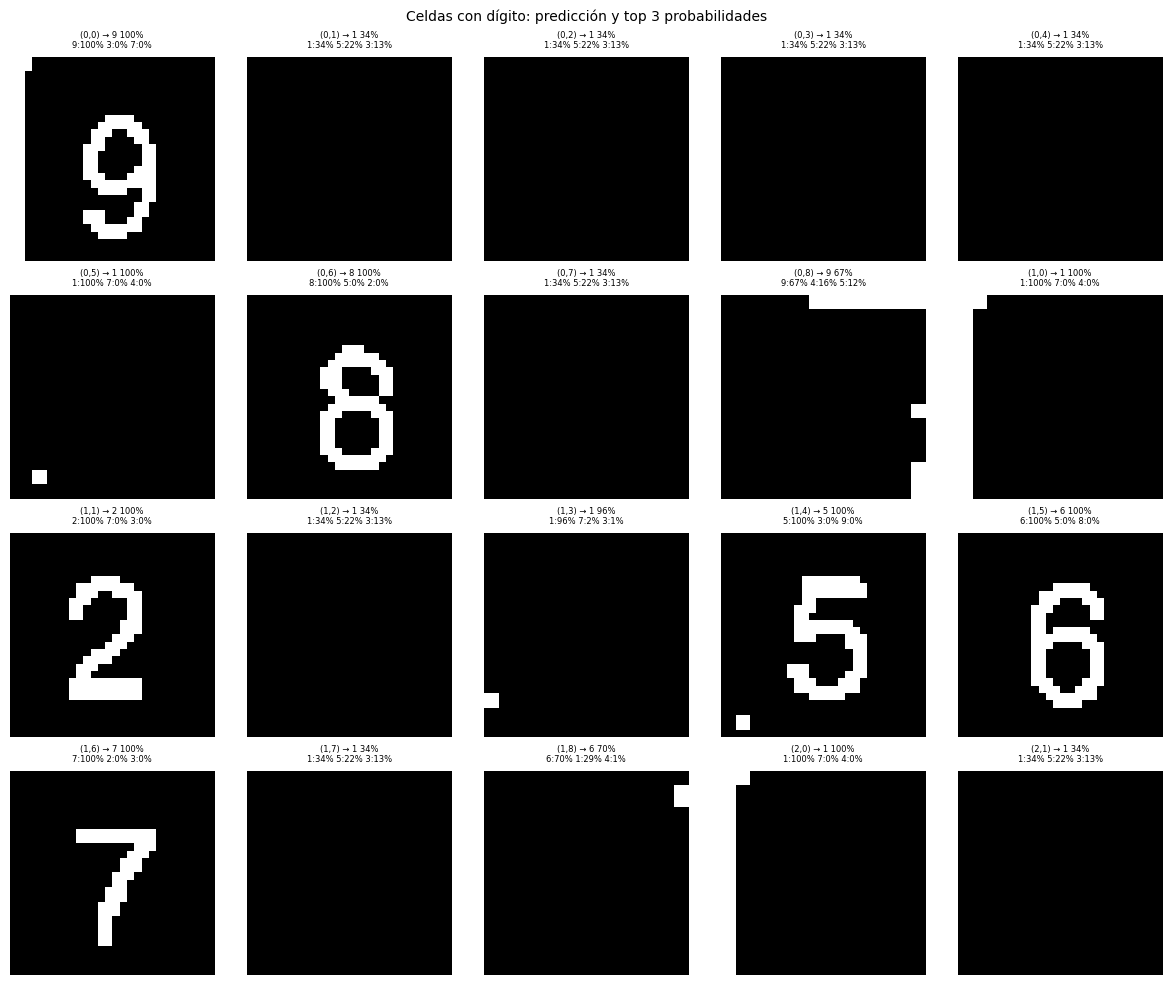

In [31]:
# ============================================
# DIAGNÓSTICO: ¿QUÉ VE LA CNN EN CADA CELDA?
# ============================================

# Mostrar las primeras 20 celdas con dígito junto a su predicción
celdas_con_digito = [(i*9+j, celdas[i*9+j], i, j)
                     for i in range(9) for j in range(9)
                     if hay_digito(celdas[i*9+j])][:20]

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.flatten()

for k, (idx, celda, i, j) in enumerate(celdas_con_digito):
    entrada = celda.reshape(1, 28, 28, 1)
    pred    = modelo_cnn.predict(entrada, verbose=0)[0]
    pred[0] = 0.0
    pred    = pred / pred.sum()
    digito  = int(np.argmax(pred))
    confianza = float(pred[digito])

    # Mostrar también las 3 mejores predicciones
    top3_idx  = np.argsort(pred)[::-1][:3]
    top3_str  = ' '.join([f'{i}:{pred[i]:.0%}' for i in top3_idx])

    axes[k].imshow(celda, cmap='gray', vmin=0, vmax=1)
    axes[k].set_title(f'({i},{j}) → {digito} {confianza:.0%}\n{top3_str}',
                      fontsize=6)
    axes[k].axis('off')

plt.suptitle('Celdas con dígito: predicción y top 3 probabilidades', fontsize=10)
plt.tight_layout()
plt.show()

In [32]:
# Diagnóstico rápido de hay_digito()
for idx in range(20):
    i, j = idx // 9, idx % 9
    celda = celdas[idx]
    area_bruta = float(np.sum(celda > 0.5) / (28*28))
    tiene, prop = hay_digito(celda), 0
    print(f"({i},{j}): área bruta={area_bruta:.1%}  hay_digito={tiene}")

(0,0): área bruta=18.2%  hay_digito=(True, 0.14923469387755103)
(0,1): área bruta=0.0%  hay_digito=(False, 0.0)
(0,2): área bruta=0.0%  hay_digito=(False, 0.0)
(0,3): área bruta=0.0%  hay_digito=(False, 0.0)
(0,4): área bruta=0.0%  hay_digito=(False, 0.0)
(0,5): área bruta=0.5%  hay_digito=(False, 0.0)
(0,6): área bruta=12.0%  hay_digito=(True, 0.15625)
(0,7): área bruta=0.0%  hay_digito=(False, 0.0)
(0,8): área bruta=5.9%  hay_digito=(False, 0.0)
(1,0): área bruta=7.7%  hay_digito=(False, 0.03762755102040816)
(1,1): área bruta=11.1%  hay_digito=(False, 0.06823979591836735)
(1,2): área bruta=0.0%  hay_digito=(False, 0.0)
(1,3): área bruta=0.5%  hay_digito=(False, 0.0)
(1,4): área bruta=12.5%  hay_digito=(False, 0.07206632653061225)
(1,5): área bruta=11.6%  hay_digito=(True, 0.12244897959183673)
(1,6): área bruta=7.5%  hay_digito=(False, 0.04336734693877551)
(1,7): área bruta=0.0%  hay_digito=(False, 0.0)
(1,8): área bruta=0.8%  hay_digito=(False, 0.0)
(2,0): área bruta=7.7%  hay_digito